<>:110: SyntaxWarning: invalid escape sequence '\d'
<>:110: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_155249/3290669257.py:110: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(lambda_vals, ext_salim, label='Salim et al. (2018) - ($\delta=-0.2, B=1.0$)', color='orange', linewidth=2.5, zorder=4)


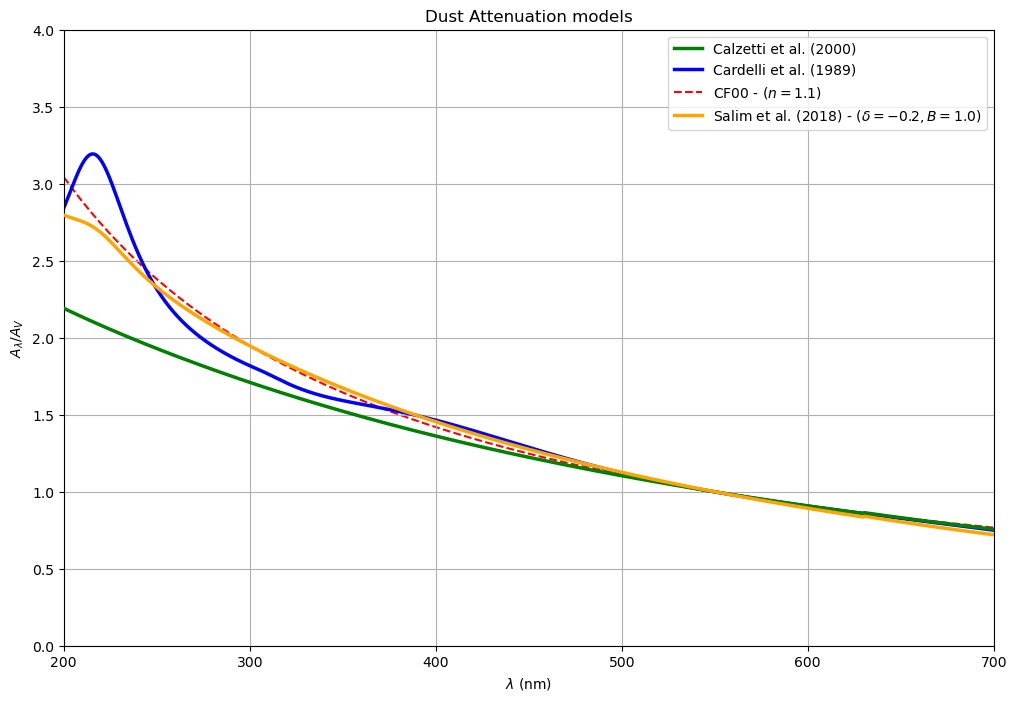

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- FUNÇÃO 1: Calzetti et al. (2000) ---
def calzetti_obscuration_raw(lambda_nm):
    """
    Calcula a curva de obscurecimento de Calzetti et al. (2000) (NÃO normalizada).
    Retorna k'(lambda).
    """
    lambda_um = lambda_nm / 1000.0
    k_raw = np.zeros_like(lambda_um)
    R_V_calzetti = 4.05
    
    # Faixa UV (0.12 <= lambda < 0.63 µm)
    uv_mask = (lambda_um >= 0.12) & (lambda_um < 0.63)
    x_uv = lambda_um[uv_mask]
    k_raw[uv_mask] = 2.659 * (-2.156 + (1.509 / x_uv) - (0.198 / x_uv**2) + (0.011 / x_uv**3)) + R_V_calzetti
    
    # Faixa Óptica/NIR (0.63 <= lambda <= 2.2 µm)
    opt_mask = (lambda_um >= 0.63) & (lambda_um <= 2.2)
    x_opt = lambda_um[opt_mask]
    k_raw[opt_mask] = 2.659 * (-1.857 + 1.040 / x_opt) + R_V_calzetti
    
    k_raw[(lambda_um < 0.12) | (lambda_um > 2.2)] = np.nan
    return k_raw

# --- FUNÇÃO 2: Cardelli et al. (1989) - COMPLETA (UV + Óptico) ---
def cardelli_extinction_full_nm(lambda_nm, Rv=3.1):
    """
    Calcula a lei de extinção completa de Cardelli et al. (1989).
    Recebe lambda em nanômetros.
    """
    x = 1000.0 / lambda_nm
    a = np.zeros_like(x, dtype=float)
    b = np.zeros_like(x, dtype=float)

    # Faixa Óptica/NIR (1.1 <= x < 3.3)
    opt_mask = (x >= 1.1) & (x < 3.3)
    y = x[opt_mask] - 1.82
    a[opt_mask] = (1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7)
    b[opt_mask] = (1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7)

    # Faixa UV (3.3 <= x < 8.0)
    uv_mask = (x >= 3.3) & (x < 8.0)
    a[uv_mask] = 1.752 - 0.316*x[uv_mask] - 0.104/((x[uv_mask] - 4.67)**2 + 0.341)
    b[uv_mask] = -3.090 + 1.825*x[uv_mask] + 1.206/((x[uv_mask] - 4.62)**2 + 0.263)
    fuv_rise_mask = (x >= 5.9)
    fuv_mask_intersect = uv_mask & fuv_rise_mask
    y_fuv = x[fuv_mask_intersect] - 5.9
    Fa = -0.04473 * y_fuv**2 - 0.009779 * y_fuv**3
    Fb = 0.2130 * y_fuv**2 + 0.1207 * y_fuv**3
    a[fuv_mask_intersect] += Fa
    b[fuv_mask_intersect] += Fb
    
    A_lambda_sobre_A_V = a + b / Rv
    A_lambda_sobre_A_V[(x < 1.1) | (x >= 8.0)] = np.nan
    return A_lambda_sobre_A_V

# --- FUNÇÃO 3: Lei de Potência (Power Law) ---
def power_law_extinction(lambda_nm, n=1.1):
    return (lambda_nm / 550.0)**(-n)

# --- FUNÇÃO 4: Perfil Drude para o "Bump" de 2175 Å ---
def drude_profile_nm(lambda_nm):
    """
    Perfil Drude para o "bump" de 2175 Å (0.2175 µm).
    """
    x0 = 4.595 # 1 / 0.2175 µm
    gamma = 1.0 # µm^-1
    x = 1000.0 / lambda_nm # em µm^-1
    return x**2 / ((x**2 - x0**2)**2 + x**2 * gamma**2)

# --- FUNÇÃO 5: Modelo de Salim et al. (2018) ---
def salim_attenuation(lambda_nm):
    """
    Calcula a curva de atenuação de Salim et al. (2018).
    """
    delta = -0.2
    B = 1.0
    Rv_mod = 3.1
    Rv_cal = 4.05
    
    k_cal = calzetti_obscuration_raw(lambda_nm)
    D_lambda = drude_profile_nm(lambda_nm)
    
    # Equação de Salim
    k_mod = k_cal * (lambda_nm / 550.0)**delta + B * D_lambda * (Rv_mod / Rv_cal)
    
    # Re-normaliza a curva para ter valor 1 em 550 nm para comparação
    k_cal_550 = calzetti_obscuration_raw(np.array([550.0]))
    D_lambda_550 = drude_profile_nm(np.array([550.0]))
    norm_factor = k_cal_550 * (550.0 / 550.0)**delta + B * D_lambda_550 * (Rv_mod / Rv_cal)
    
    return k_mod / norm_factor

# --- PLOTAGEM ---
lambda_vals = np.linspace(200, 700, 1000) # Faixa expandida para ver o "bump"

# Calcula as curvas
ext_cardelli = cardelli_extinction_full_nm(lambda_vals, Rv=3.1)
ext_calzetti_renorm = calzetti_obscuration_raw(lambda_vals) / 4.05
ext_power_law = power_law_extinction(lambda_vals, n=1.1)
ext_salim = salim_attenuation(lambda_vals)

# Cria o gráfico
plt.figure(figsize=(12, 8))
plt.plot(lambda_vals, ext_calzetti_renorm, label="Calzetti et al. (2000)", color='green', linewidth=2.5, zorder=3)
plt.plot(lambda_vals, ext_cardelli, label='Cardelli et al. (1989)', color='blue', linewidth=2.5, zorder=2)
plt.plot(lambda_vals, ext_power_law, label='CF00 - ($n=1.1$)', linestyle='--', color='red', zorder=1)
plt.plot(lambda_vals, ext_salim, label='Salim et al. (2018) - ($\delta=-0.2, B=1.0$)', color='orange', linewidth=2.5, zorder=4)

# Formatação
plt.title("Dust Attenuation models")
plt.xlabel("$\\lambda$ (nm)")
plt.ylabel("$A_\\lambda/A_V$")
plt.legend()
plt.grid(True)
plt.xlim(200, 700)
plt.ylim(0, 4.0)

# Salva a figura
plt.show()